<a href="https://colab.research.google.com/github/jheyson1984/reglog-demora-cancer-155/blob/main/notebooks/RegLog_demora_cancer_155.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Regresión logística: demora mayor a 90 días entre inicio de síntomas y consulta en cáncer de mama y cuello uterino (Colombia, 2025)

**Curso:** Introducción a Machine Learning (604027), Universidad de Cundinamarca
**Autor:** Jheyson Morales
**Datos:** microdatos del Instituto Nacional de Salud, evento 155, año 2025 (Portal SIVIGILA)

**Objetivo:** predecir si una mujer tardó más de 90 días entre el inicio de síntomas y la consulta (1 = sí, 0 = no), a partir de departamento de residencia, edad, régimen de afiliación, estrato y área.

**Etapas:** 1. Carga y limpieza. 2. Variable objetivo. 3. Pistas y división. 4. Escalado. 5. Entrenamiento. 6. Evaluación. 7. Odds ratio.



In [ ]:
# Subir la base del INS al cuaderno
from google.colab import files
subido = files.upload()

In [2]:
# Etapa 1: abrir la base del INS (evento 155, año 2025)
import pandas as pd

datos = pd.read_excel("Datos_2025_155.xlsx")
print(datos.shape)   # filas, columnas

(18717, 69)


In [3]:
# Convertir las dos fechas de texto a fecha
datos["INI_SIN"] = pd.to_datetime(datos["INI_SIN"].str[:10].str.strip(), format="%d/%m/%Y")
datos["FEC_CON"] = pd.to_datetime(datos["FEC_CON"].str[:10].str.strip(), format="%d/%m/%Y")

# Demora en días: fecha de consulta menos inicio de síntomas
datos["demora"] = (datos["FEC_CON"] - datos["INI_SIN"]).dt.days

print(datos["demora"].describe())

count    18717.000000
mean        87.009029
std        207.348777
min          0.000000
25%         12.000000
50%         36.000000
75%         92.000000
max       8087.000000
Name: demora, dtype: float64


In [4]:
# Etapa 1: limpieza (tres exclusiones)
datos["estrato"] = datos["estrato"].astype(str).str.strip()

limpios = datos[(datos["demora"] <= 365)
                & (datos["estrato"] != "")
                & (datos["Departamento_residencia"] != "EXTERIOR")].copy()

limpios["estrato"] = limpios["estrato"].astype(int)

print("Excluidos:", len(datos) - len(limpios))
print("Analizados:", len(limpios))

Excluidos: 1391
Analizados: 17326


In [5]:
# Etapa 2: porcentaje de casos que supera cada punto de corte candidato
print("Más de 30 días:", round((limpios["demora"] > 30).mean() * 100, 1), "%")
print("Más de 60 días:", round((limpios["demora"] > 60).mean() * 100, 1), "%")
print("Más de 90 días:", round((limpios["demora"] > 90).mean() * 100, 1), "%")

Más de 30 días: 54.6 %
Más de 60 días: 34.2 %
Más de 90 días: 22.8 %


In [6]:
# Etapa 2: variable objetivo (1 = más de 90 días, 0 = 90 días o menos)
limpios["demorada"] = (limpios["demora"] > 90).astype(int)

print(limpios["demorada"].value_counts())

demorada
0    13368
1     3958
Name: count, dtype: int64


In [7]:
# Etapa 3: revisar cómo vienen escritas las categorías de las pistas
print(limpios["TIP_SS"].value_counts())
print(limpios["AREA"].value_counts())
print(limpios["Departamento_residencia"].value_counts().head(5))

TIP_SS
C    10165
S     6319
P      673
N       80
I       68
E       21
Name: count, dtype: int64
AREA
1    15555
3     1045
2      726
Name: count, dtype: int64
Departamento_residencia
BOGOTA          4672
ANTIOQUIA       2570
VALLE           1560
CUNDINAMARCA     957
ATLANTICO        899
Name: count, dtype: int64


In [8]:
# Etapa 3: pistas (X) y respuesta (y)
pistas = limpios[["Departamento_residencia", "EDAD", "TIP_SS", "estrato", "AREA"]]

X = pd.get_dummies(pistas, columns=["Departamento_residencia", "TIP_SS", "AREA"], dtype=int)

# Quitar la categoría de referencia de cada pista
X = X.drop(columns=["Departamento_residencia_BOGOTA", "TIP_SS_C", "AREA_1"])

y = limpios["demorada"]

print(X.shape)

(17326, 41)


In [9]:
# Etapa 3: división en aprendizaje (75 %) y examen (25 %)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print("Aprendizaje:", len(X_train), "| demoradas:", round(y_train.mean() * 100, 1), "%")
print("Examen:", len(X_test), "| demoradas:", round(y_test.mean() * 100, 1), "%")

Aprendizaje: 12994 | demoradas: 22.8 %
Examen: 4332 | demoradas: 22.9 %


In [10]:
# Valor más alto de tres pistas
print("Edad máxima:", X_train["EDAD"].max())
print("Estrato máximo:", X_train["estrato"].max())
print("Máximo en la columna de Antioquia:", X_train["Departamento_residencia_ANTIOQUIA"].max())

Edad máxima: 99
Estrato máximo: 6
Máximo en la columna de Antioquia: 1


In [11]:
# Etapa 4: escalar edad y estrato
from sklearn.preprocessing import StandardScaler

X_train = X_train.astype(float)
X_test = X_test.astype(float)

cols = ["EDAD", "estrato"]
escalador = StandardScaler()
X_train[cols] = escalador.fit_transform(X_train[cols])
X_test[cols] = escalador.transform(X_test[cols])

print(X_train[cols].describe().round(2))

           EDAD   estrato
count  12994.00  12994.00
mean      -0.00     -0.00
std        1.00      1.00
min       -2.35     -1.22
25%       -0.80     -0.22
50%       -0.09     -0.22
75%        0.75      0.77
max        3.01      3.76


In [12]:
# Etapa 5: entrenar el modelo y pedirle respuestas
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
print(pd.Series(y_pred).value_counts())

0    4210
1     122
Name: count, dtype: int64


In [13]:
# Etapa 6: realidad contra lo que dijo el modelo
tabla = pd.crosstab(y_test, y_pred, rownames=["Realidad"], colnames=["Modelo dijo"])
print(tabla)

Modelo dijo     0   1
Realidad             
0            3285  57
1             925  65


In [14]:
# Etapa 6: medidas del modelo
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, target_names=["No demorada", "Demorada"]))

Accuracy: 0.773
              precision    recall  f1-score   support

 No demorada       0.78      0.98      0.87      3342
    Demorada       0.53      0.07      0.12       990

    accuracy                           0.77      4332
   macro avg       0.66      0.52      0.49      4332
weighted avg       0.72      0.77      0.70      4332



In [15]:
# Etapa 5: segundo modelo, con manejo del desbalance
modelo_bal = LogisticRegression(max_iter=1000, class_weight="balanced")
modelo_bal.fit(X_train, y_train)

y_pred_bal = modelo_bal.predict(X_test)
print(pd.crosstab(y_test, y_pred_bal, rownames=["Realidad"], colnames=["Modelo dijo"]))

Modelo dijo     0     1
Realidad               
0            2264  1078
1             444   546


In [16]:
# Etapa 6: medidas del segundo modelo
print("Accuracy:", round(accuracy_score(y_test, y_pred_bal), 3))
print(classification_report(y_test, y_pred_bal, target_names=["No demorada", "Demorada"]))

Accuracy: 0.649
              precision    recall  f1-score   support

 No demorada       0.84      0.68      0.75      3342
    Demorada       0.34      0.55      0.42       990

    accuracy                           0.65      4332
   macro avg       0.59      0.61      0.58      4332
weighted avg       0.72      0.65      0.67      4332



In [17]:
# Etapa 6: probabilidades del primer modelo
prob = modelo.predict_proba(X_test)[:, 1]

comparacion = pd.DataFrame({
    "Realidad": y_test.values,
    "Probabilidad_de_demora": prob.round(2),
    "Modelo_dijo": y_pred
})
print(comparacion.head(10))

   Realidad  Probabilidad_de_demora  Modelo_dijo
0         1                    0.38            0
1         0                    0.26            0
2         0                    0.12            0
3         0                    0.24            0
4         0                    0.17            0
5         1                    0.30            0
6         0                    0.44            0
7         1                    0.63            1
8         0                    0.27            0
9         1                    0.10            0


In [18]:
# Etapa 6: bajar el umbral de 0,50 a 0,25 en el primer modelo
umbral = 0.25
y_pred_umbral = (prob >= umbral).astype(int)

print(pd.crosstab(y_test, y_pred_umbral, rownames=["Realidad"], colnames=["Modelo dijo"]))

Modelo dijo     0    1
Realidad              
0            2495  847
1             522  468


In [19]:
# Etapa 7: odds ratio de las pistas (primer modelo)
import numpy as np

odds = pd.Series(np.exp(modelo.coef_[0]), index=X_train.columns)
print(odds.loc[["EDAD", "estrato", "TIP_SS_S", "AREA_2", "AREA_3"]].round(2))

EDAD        1.07
estrato     0.93
TIP_SS_S    1.25
AREA_2      1.08
AREA_3      1.37
dtype: float64


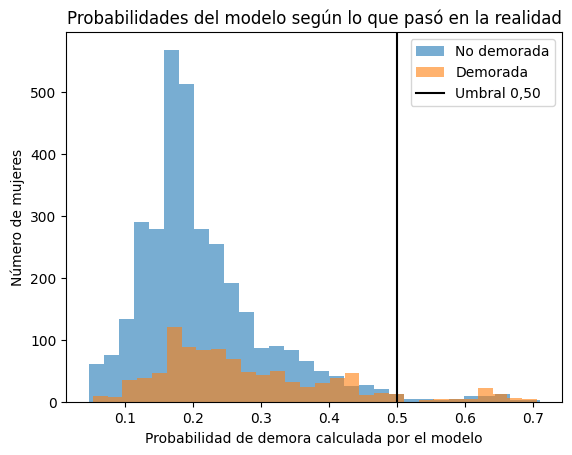

In [20]:
# Etapa 6: gráfico de las probabilidades según la realidad
import matplotlib.pyplot as plt

plt.hist(prob[y_test.values == 0], bins=30, alpha=0.6, label="No demorada")
plt.hist(prob[y_test.values == 1], bins=30, alpha=0.6, label="Demorada")
plt.axvline(0.5, color="black", label="Umbral 0,50")
plt.xlabel("Probabilidad de demora calculada por el modelo")
plt.ylabel("Número de mujeres")
plt.title("Probabilidades del modelo según lo que pasó en la realidad")
plt.legend()
plt.show()

## Interpretación de resultados

**Datos.** De 18.717 registros se analizaron 17.326, tras excluir 1.391 por demora mayor a 365 días, estrato vacío o residencia en el exterior. El 22,8 % de las mujeres (3.958) tardó más de 90 días en consultar, así que las dos clases están desbalanceadas.

**Modelo 1, umbral 0,50.** El accuracy fue 0,773, pero el recall de la clase "demorada" fue 0,07: encontró 65 de 990. Responder "no" a todas daría un accuracy de 0,771, casi el mismo. Por eso el accuracy solo no sirve para evaluar este modelo.

**Manejo del desbalance.** Con `class_weight="balanced"` (modelo 2) el recall subió a 0,55 (546 de 990), la precision bajó a 0,34 y el accuracy bajó a 0,649. Bajar el umbral del modelo 1 a 0,25 produjo un efecto parecido: encontró 468 de 990, con 847 falsas alarmas.

**Elección.** Escogería el modelo 2, porque lo que se necesita es identificar a las mujeres que sí se demoran para hacerles seguimiento. El costo es hacer seguimientos que no eran necesarios.

**Odds ratio (modelo 1).** Régimen subsidiado frente a contributivo: 1,25. Rural disperso frente a cabecera: 1,37. Centro poblado frente a cabecera: 1,08. Edad: 1,07 y estrato: 0,93, ambos por cada desviación estándar.

**Limitación.** El histograma muestra que las probabilidades de las demoradas y las no demoradas se superponen. Las cinco pistas usadas separan poco a los dos grupos; para predecir mejor harían falta otras variables.